**Table of contents**<a id='toc0_'></a>    
- [Example fluorescence trajectories at different irradiances - 4 fluorophores, 3 nm, no OET](#toc1_)    
  - [Reading the data](#toc1_1_)    
    - [Irradiance 100 %](#toc1_1_1_)    
    - [Irradiance 50 %](#toc1_1_2_)    
    - [Irradiance 25 %](#toc1_1_3_)    
    - [Irradiance 10 %](#toc1_1_4_)    
    - [Irradiance 1 %](#toc1_1_5_)    
  - [Figure](#toc1_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Example fluorescence trajectories at different irradiances - 4 fluorophores, 3 nm, no OET](#toc0_)

In [ ]:
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

import fluopy.blinking as bl
import fluopy.emissions as em
import fluopy.fcs as fcs_p
import fluopy.fluorophores as fl
import fluopy.formulas as fo
import fluopy.simulation as si
import fluopy.prediction as pr
import fluopy.analysis as an
import fluopy.transitions as tr
import fluopy.routines as rt

%load_ext autoreload
%autoreload 2


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

reading_from = r"D:\python_output\Chapter_I\1_11_multi_f_et_irradiance\noOET"

fluopy.blinking version: 0.1.0
fluopy.emissions version: 0.1.0
fluopy.fcs version: 0.1.0
fluopy.fluorophores version: 0.1.0
fluopy.formulas version: 0.1.0
fluopy.simulation version: 0.1.0
fluopy.prediction version: 0.1.0
fluopy.analysis version: 0.1.0
fluopy.transitions version: 0.1.0
fluopy.routines version: 0.1.0


## <a id='toc1_1_'></a>[Reading the data](#toc0_)

### <a id='toc1_1_1_'></a>[Irradiance 100 %](#toc0_)

In [2]:
read_from = reading_from + r"\irradiance100"
df100 = pd.read_parquet(read_from + r"\emission_df.parquet")

### <a id='toc1_1_2_'></a>[Irradiance 50 %](#toc0_)

In [3]:
read_from = reading_from + r"\irradiance50"
df50 = pd.read_parquet(read_from + r"\emission_df.parquet")

### <a id='toc1_1_3_'></a>[Irradiance 25 %](#toc0_)

In [4]:
read_from = reading_from + r"\irradiance25"
df25 = pd.read_parquet(read_from + r"\emission_df.parquet")

### <a id='toc1_1_4_'></a>[Irradiance 10 %](#toc0_)

In [5]:
read_from = reading_from + r"\irradiance10"
df10 = pd.read_parquet(read_from + r"\emission_df.parquet")

### <a id='toc1_1_5_'></a>[Irradiance 1 %](#toc0_)

In [6]:
read_from = reading_from + r"\irradiance1"
df1 = pd.read_parquet(read_from + r"\emission_df.parquet")

## <a id='toc1_2_'></a>[Figure](#toc0_)

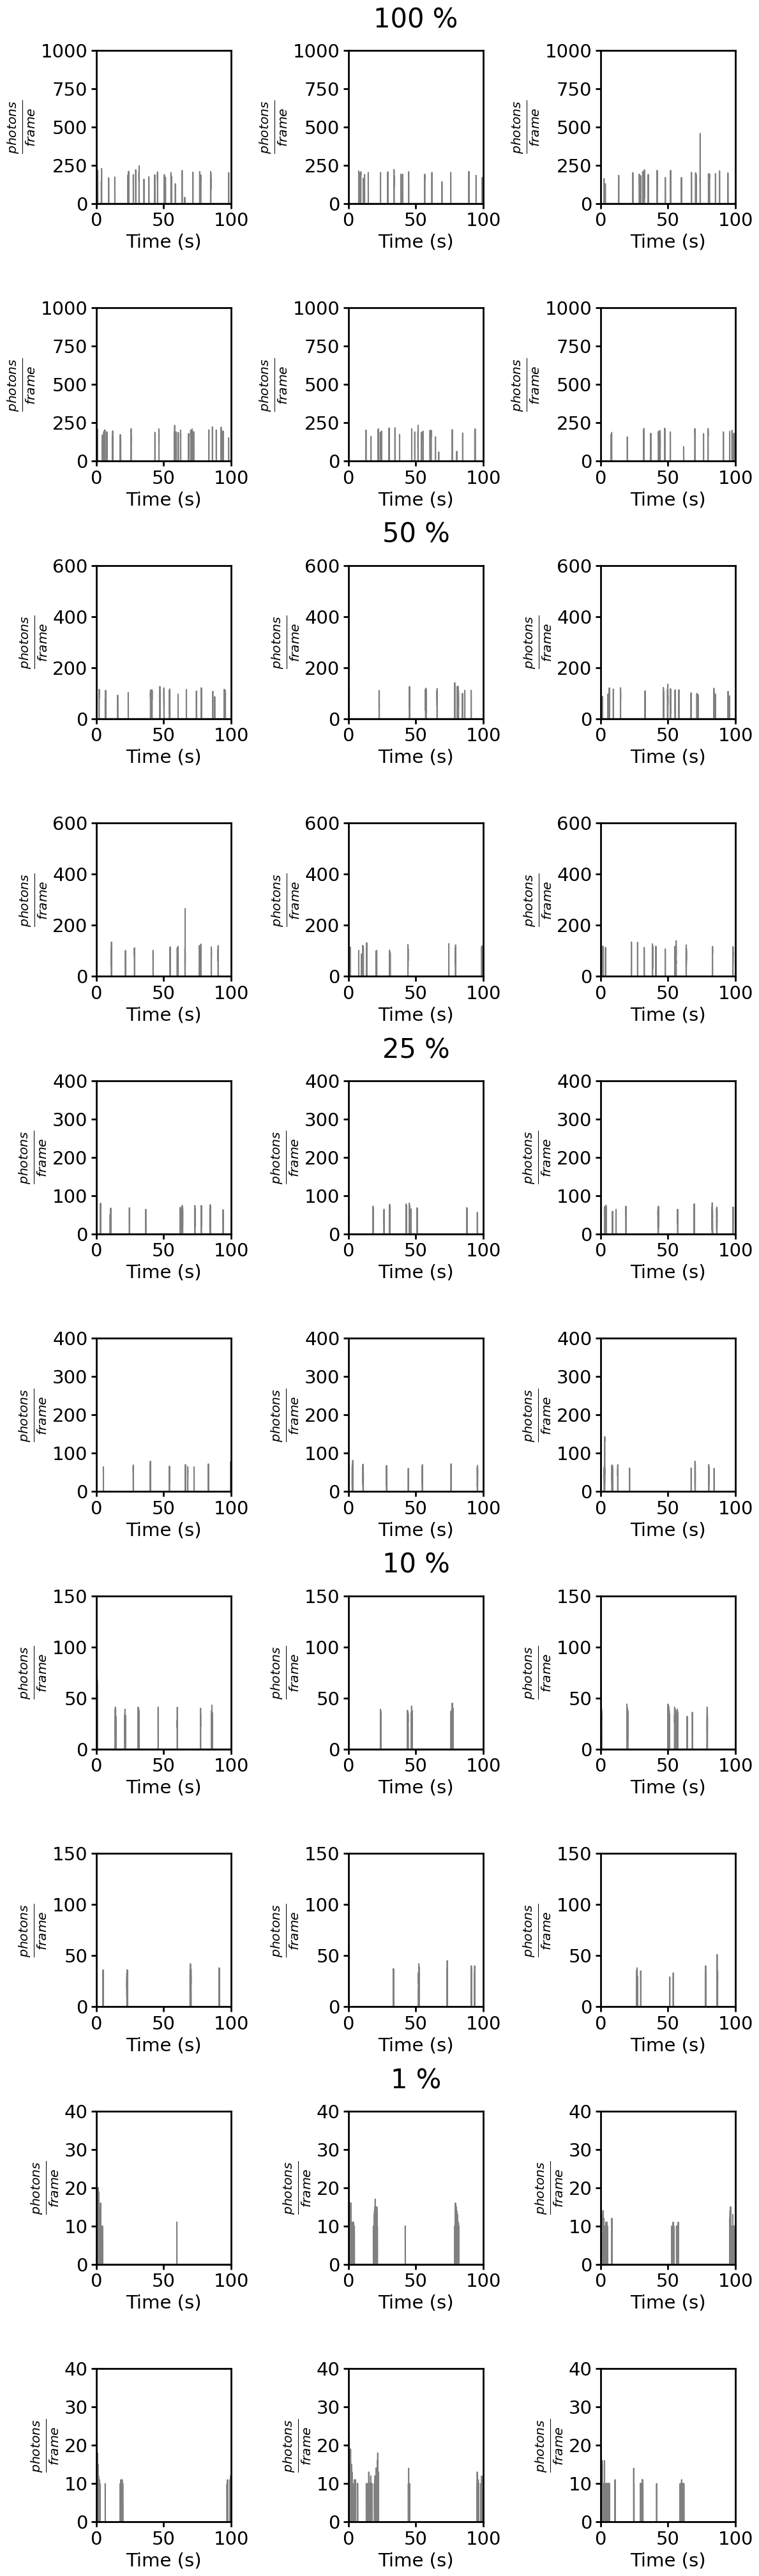

: 

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(10, 3)
fig = plt.figure(figsize=(12, 40.5))
emis = em.Emissions()


def plot1(data, start_row, label, ylim):
    for i, col in enumerate(data.columns):
        if i < 3:
            ax = fig.add_subplot(gs[start_row, i])
        else:
            ax = fig.add_subplot(gs[start_row + 1, i - 3])
        if i == 1:
            ax.text(
                0.5,
                1.2,
                label,
                ha="center",
                va="center",
                fontsize=30,
                transform=ax.transAxes,
            )
        emis.event_time_series = data[col]
        emis.plot_time_series(xlim=[0, 100], ylim=[0, ylim], axes=ax, color="grey")


plot1(df100, 0, "100 %", 1000)
plot1(df50, 2, "50 %", 600)
plot1(df25, 4, "25 %", 400)
plot1(df10, 6, "10 %", 150)
plot1(df1, 8, "1 %", 40)

fig.tight_layout()